# 矩阵求导入门 - 可视化

本 Notebook 生成三张图：
1. 矩阵求导形状检查示意
2. 线性回归损失等高线与梯度方向
3. 解析梯度 vs 数值梯度对比

输出目录：`assets/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assets_dir = Path.cwd() / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)
assets_dir

WindowsPath('D:/BBFEC-FRONT/RL-AND-RL/01_数学基础/02_线性代数/assets')

## 图1：矩阵求导形状检查

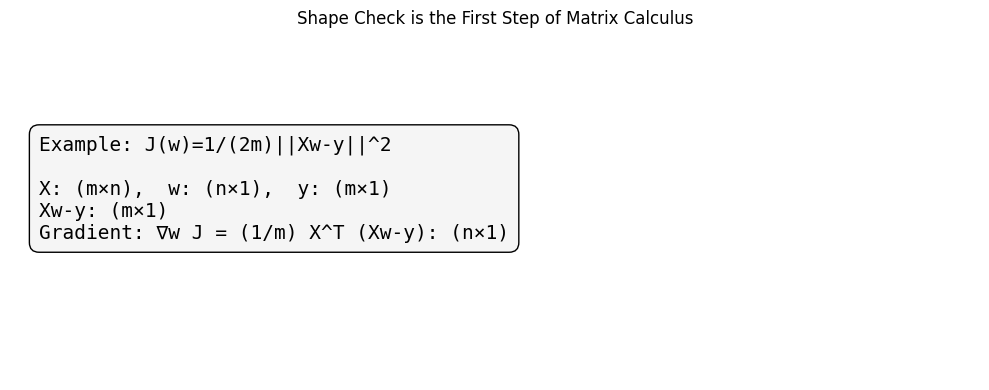

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

text = (
    'Example: J(w)=1/(2m)||Xw-y||^2\n\n'
    'X: (m×n),  w: (n×1),  y: (m×1)\n'
    'Xw-y: (m×1)\n'
    'Gradient: ∇w J = (1/m) X^T (Xw-y): (n×1)'
)
ax.text(0.03, 0.55, text, fontsize=14, va='center', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', fc='#f5f5f5', ec='black'))
ax.set_title('Shape Check is the First Step of Matrix Calculus')
plt.tight_layout()
plt.savefig(assets_dir / '25_matrix_derivative_shapes.png', dpi=160)
plt.show()

## 准备一个二维线性回归小数据

In [3]:
# X含偏置项列和1个特征列
X = np.array([[1., 0.], [1., 1.], [1., 2.], [1., 3.]])
y = np.array([1., 2., 2., 4.])
m = len(y)

def J(w):
    r = X @ w - y
    return 0.5/m * (r @ r)

def grad(w):
    return (1/m) * (X.T @ (X @ w - y))

## 图2：损失等高线与梯度方向

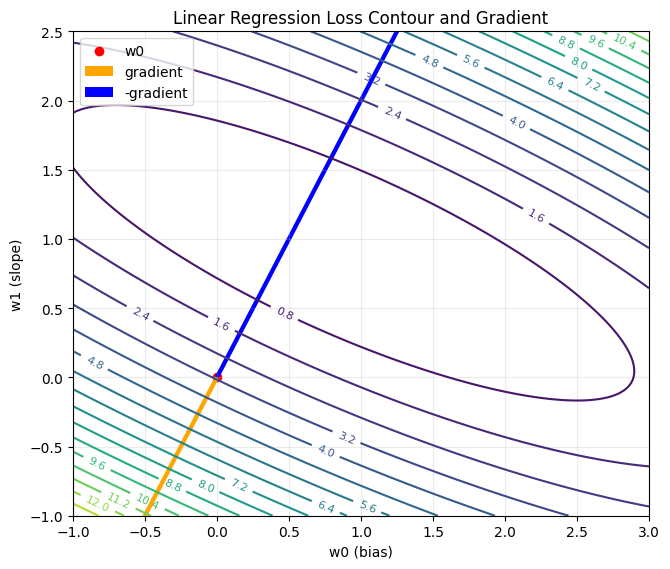

In [4]:
w0 = np.array([0.0, 0.0])
g0 = grad(w0)

w1_vals = np.linspace(-1, 3, 140)
w2_vals = np.linspace(-1, 2.5, 140)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        Z[i,j] = J(np.array([W1[i,j], W2[i,j]]))

plt.figure(figsize=(6.8,5.8))
cs = plt.contour(W1, W2, Z, levels=20)
plt.clabel(cs, inline=True, fontsize=8)
plt.scatter([w0[0]], [w0[1]], c='red', label='w0')
plt.quiver(w0[0], w0[1], g0[0], g0[1], angles='xy', scale_units='xy', scale=1, color='orange', label='gradient')
plt.quiver(w0[0], w0[1], -g0[0], -g0[1], angles='xy', scale_units='xy', scale=1, color='blue', label='-gradient')
plt.xlabel('w0 (bias)')
plt.ylabel('w1 (slope)')
plt.title('Linear Regression Loss Contour and Gradient')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '26_lr_contour_gradient.png', dpi=160)
plt.show()

## 图3：解析梯度 vs 数值梯度

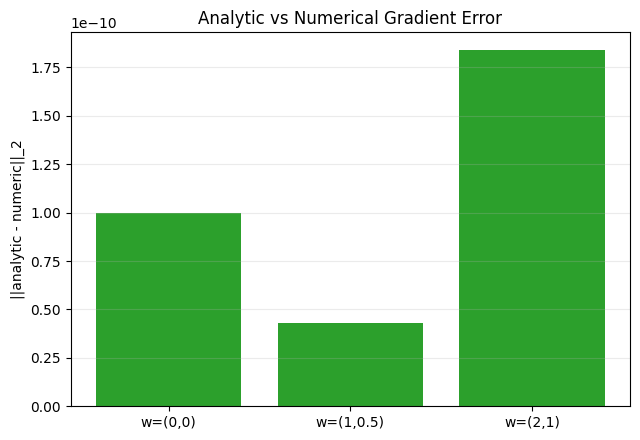

In [5]:
def numerical_grad(func, w, eps=1e-6):
    g = np.zeros_like(w)
    for i in range(len(w)):
        wp = w.copy(); wm = w.copy()
        wp[i] += eps; wm[i] -= eps
        g[i] = (func(wp) - func(wm)) / (2*eps)
    return g

test_points = [np.array([0.0,0.0]), np.array([1.0,0.5]), np.array([2.0,1.0])]
ana_err = []
for w in test_points:
    ga = grad(w)
    gn = numerical_grad(J, w)
    ana_err.append(np.linalg.norm(ga-gn))

plt.figure(figsize=(6.5,4.5))
plt.bar(['w=(0,0)','w=(1,0.5)','w=(2,1)'], ana_err, color='tab:green')
plt.ylabel('||analytic - numeric||_2')
plt.title('Analytic vs Numerical Gradient Error')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(assets_dir / '27_analytic_vs_numeric_grad.png', dpi=160)
plt.show()

### 输出文件
- `assets/25_matrix_derivative_shapes.png`
- `assets/26_lr_contour_gradient.png`
- `assets/27_analytic_vs_numeric_grad.png`